# Rainbow DQN V2 with OpenSpiel 2048

**V2 improvements:** One-hot state encoding (16→256) + Reward Shaping (corner/empty/monotonicity)

Version cải tiến từ DQN gốc, kết hợp **5 trong 6 kỹ thuật của Rainbow** (2017, DeepMind):

| Kỹ thuật | Mô tả ngắn |
|---|---|
| ✅ **Double DQN** | Giảm overestimation bằng cách tách chọn/đánh giá action |
| ✅ **Dueling Networks** | Tách V(s) + A(s,a), học tốt hơn khi reward thưa |
| ✅ **Prioritized Replay (PER)** | Sample ký ức có TD-error lớn nhiều hơn |
| ✅ **Multi-step Returns (n=3)** | Bootstrap xa hơn, propagate reward nhanh hơn |
| ✅ **Noisy Nets** | Thay ε-greedy bằng noise học được trong weights |
| ⬜ Distributional RL | C51 — phức tạp, bỏ qua |

**Cải tiến thêm cho 2048:**
- **Log2 state encoding**: tile values → log2(tile+1)/11 (chuẩn hóa tốt hơn raw values)
- **Reward scaling (EfficientZero)**: scale reward tránh gradient exploding
- **Soft target update (τ)**: thay vì copy hard mỗi 250 steps

In [ ]:
!python -V
!pip -q install --upgrade pip
!pip -q install open-spiel torch matplotlib imageio tqdm

Python 3.12.13
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 39.9 MB/s eta 0:00:00


In [ ]:
import random
import re
from collections import deque, namedtuple

import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import pyspiel

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

PyTorch version: 2.10.0+cu128
CUDA available: True
Device: cuda


## 1. Helper functions (giữ nguyên từ bản gốc)

In [ ]:
def legal_actions(state, player_id=0):
    try:
        return list(state.legal_actions(player_id))
    except TypeError:
        return list(state.legal_actions())


def sample_chance_action(state, rng):
    outcomes = state.chance_outcomes()
    actions, probs = zip(*outcomes)
    idx = rng.choice(len(actions), p=np.asarray(probs, dtype=np.float64))
    return actions[idx]


def auto_resolve_chance_nodes(state, rng):
    """Tự động xử lý chance nodes (đặt tile ngẫu nhiên sau mỗi nước đi)."""
    while state.is_chance_node() and not state.is_terminal():
        a = sample_chance_action(state, rng)
        state.apply_action(a)
    return state


def state_return(state, player_id=0):
    """Tổng reward tích lũy từ đầu game."""
    vals = state.returns()
    return float(vals[player_id]) if len(vals) > player_id else 0.0


def state_reward(state, player_id=0):
    vals = state.rewards()
    return float(vals[player_id]) if len(vals) > player_id else 0.0


def parse_board_numbers(state):
    """Đọc board từ text → numpy 4x4."""
    import re
    txt = str(state)
    nums = [int(x) for x in re.findall(r"\d+", txt)]
    if len(nums) >= 16:
        nums = nums[-16:]
        return np.array(nums, dtype=np.int64).reshape(4, 4)
    return None


def make_legal_mask(num_actions, legal_actions_list):
    mask = np.zeros(num_actions, dtype=np.float32)
    mask[legal_actions_list] = 1.0
    return mask


def extract_obs_raw(state, player_id=0):
    """Lấy raw observation từ OpenSpiel state."""
    for fn_name, args in [
        ("observation_tensor", (player_id,)),
        ("observation_tensor", tuple()),
        ("information_state_tensor", (player_id,)),
        ("information_state_tensor", tuple()),
    ]:
        fn = getattr(state, fn_name, None)
        if fn is None:
            continue
        try:
            obs = fn(*args)
            return np.asarray(obs, dtype=np.float32).reshape(-1)
        except TypeError:
            pass
    raise RuntimeError("Could not extract an observation tensor from state.")


# Các tile value có thể xuất hiện trong 2048
TILE_VALUES = [0, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096, 8192, 16384, 32768]
TILE_TO_IDX = {v: i for i, v in enumerate(TILE_VALUES)}
OBS_DIM_ONEHOT = 16 * len(TILE_VALUES)  # 16 ô × 16 giá trị có thể = 256


def extract_obs(state, player_id=0):
    """
    [V2 - CẢI TIẾN] One-hot encoding thay vì log2.

    Tại sao tốt hơn log2?
    - Log2: tile 2 → 0.09, tile 4 → 0.18  (network phải học sự khác biệt nhỏ)
    - One-hot: tile 2 → [0,1,0,...,0], tile 4 → [0,0,1,...,0]  (phân biệt rõ ràng)

    Output shape: (256,) thay vì (16,)
    """
    raw = extract_obs_raw(state, player_id)   # (16,) — raw tile values
    onehot = np.zeros((16, len(TILE_VALUES)), dtype=np.float32)
    for i, val in enumerate(raw):
        idx = TILE_TO_IDX.get(int(val), 0)   # tile không biết → index 0 (ô trống)
        onehot[i, idx] = 1.0
    return onehot.reshape(-1)                 # (256,)


def shaped_reward(board, raw_reward):
    """
    [V2 - CẢI TIẾN] Reward shaping — dạy agent chiến lược 2048.

    Ngoài điểm merge, thưởng thêm cho:
    1. Corner bonus:  tile lớn nhất nằm ở 1 trong 4 góc
    2. Empty bonus:   nhiều ô trống = dễ xoay sở hơn
    3. Mono score:    tiles xếp theo thứ tự giảm dần (chiến lược snake)

    board: numpy 4x4 array
    raw_reward: điểm merge từ step() (delta cumulative return)
    """
    if board is None:
        return raw_reward

    max_tile = board.max()

    # 1. Corner bonus: tile lớn nhất ở góc thì thưởng
    corners = [board[0, 0], board[0, 3], board[3, 0], board[3, 3]]
    corner_bonus = max_tile * 0.1 if max_tile in corners else 0.0

    # 2. Empty bonus: mỗi ô trống thưởng nhỏ
    empty_cells = int(np.sum(board == 0))
    empty_bonus = empty_cells * 2.0

    # 3. Monotonicity score: kiểm tra hàng và cột xếp thứ tự tăng/giảm dần
    mono_score = 0.0
    for row in board:
        for i in range(3):
            if row[i] >= row[i + 1]:
                mono_score += row[i] * 0.01
    for col in board.T:
        for i in range(3):
            if col[i] >= col[i + 1]:
                mono_score += col[i] * 0.01

    return raw_reward + corner_bonus + empty_bonus + mono_score


def reward_transform(x):
    """
    [EfficientZero] Scale reward để tránh gradient exploding.
    Áp dụng SAU khi đã shape reward (Cách A).
    h(x) = sign(x) * (sqrt(|x| + 1) - 1) + eps * x
    """
    eps = 0.001
    return np.sign(x) * (np.sqrt(np.abs(x) + 1) - 1) + eps * x


# Kiểm tra
game = pyspiel.load_game("2048")
test_state = game.new_initial_state()
auto_resolve_chance_nodes(test_state, np.random.default_rng(0))
obs = extract_obs(test_state)
print("[V2] One-hot obs shape:", obs.shape)        # phải là (256,)
print("[V2] One-hot obs non-zero:", obs.sum())     # phải là 16 (mỗi ô 1 bit)
print("[V2] OBS_DIM_ONEHOT =", OBS_DIM_ONEHOT)


[V2] One-hot obs shape: (256,)
[V2] One-hot obs non-zero: 16.0
[V2] OBS_DIM_ONEHOT = 256


## 2. Environment wrapper (giữ nguyên từ bản gốc, dùng log2 obs)

In [ ]:
class OpenSpiel2048Env:
    def __init__(self, seed=42):
        self.game = pyspiel.load_game("2048")
        self.player_id = 0
        self.num_actions = self.game.num_distinct_actions()
        self.obs_dim = OBS_DIM_ONEHOT   # [V2] 256 thay vì 16
        self.rng = np.random.default_rng(seed)
        self.state = None

    def reset(self, seed=None):
        if seed is not None:
            self.rng = np.random.default_rng(seed)
        self.state = self.game.new_initial_state()
        auto_resolve_chance_nodes(self.state, self.rng)
        return extract_obs(self.state, self.player_id)   # one-hot (256,)

    def step(self, action):
        if self.state is None:
            raise RuntimeError("Call reset() before step().")
        if self.state.is_terminal():
            raise RuntimeError("Episode already ended. Call reset().")

        legal = legal_actions(self.state, self.player_id)
        if action not in legal:
            raise ValueError(f"Illegal action {action}. Legal: {legal}")

        prev_return = state_return(self.state, self.player_id)
        self.state.apply_action(int(action))
        auto_resolve_chance_nodes(self.state, self.rng)

        next_obs = extract_obs(self.state, self.player_id) if not self.state.is_terminal() \
                   else np.zeros(self.obs_dim, dtype=np.float32)
        new_return = state_return(self.state, self.player_id)

        raw_reward = new_return - prev_return

        # [V2 - Cách A] Shape trước → transform sau
        board = parse_board_numbers(self.state)
        shaped = shaped_reward(board, raw_reward)
        reward = reward_transform(shaped)

        done = self.state.is_terminal()
        info = {
            "legal_actions": legal_actions(self.state, self.player_id) if not done else [],
            "state_return": new_return,
            "board": board,
            "state_text": str(self.state),
        }
        return next_obs, float(reward), done, info

    def legal_actions(self):
        if self.state is None or self.state.is_terminal():
            return []
        return legal_actions(self.state, self.player_id)

    def render(self):
        if self.state is None:
            print("<env not reset>")
        else:
            print(self.state)


## 3. [Rainbow] Prioritized Experience Replay (PER)

Thay vì sample đều (uniform), PER ưu tiên những transition có **TD-error lớn** — tức là những gì agent đang dự đoán sai nhiều nhất.

Dùng **Sum-Tree** để sample O(log N) thay vì O(N):
- `α` (alpha): mức độ ưu tiên hóa (0 = uniform, 1 = full priority)
- `β` (beta): importance sampling correction (tăng dần từ 0.4 → 1.0 trong quá trình train)

In [ ]:
class SumTree:
    """
    Binary sum tree để sample O(log N).
    Lá cây = priority của từng transition.
    Node cha = tổng priority của 2 con.
    Root = tổng tất cả priorities.
    """
    def __init__(self, capacity):
        self.capacity = capacity
        self.tree = np.zeros(2 * capacity - 1, dtype=np.float64)  # node tree
        self.data = [None] * capacity                              # dữ liệu thực
        self.write_ptr = 0   # con trỏ ghi (circular)
        self.n_entries = 0   # số entries hiện có

    def _propagate(self, idx, change):
        """Update từ leaf lên root."""
        parent = (idx - 1) // 2
        self.tree[parent] += change
        if parent != 0:
            self._propagate(parent, change)

    def _retrieve(self, idx, s):
        """Tìm leaf có cumulative sum >= s."""
        left = 2 * idx + 1
        right = left + 1
        if left >= len(self.tree):  # đã đến lá
            return idx
        if s <= self.tree[left]:
            return self._retrieve(left, s)
        else:
            return self._retrieve(right, s - self.tree[left])

    def total(self):
        return self.tree[0]  # root = tổng tất cả

    def add(self, priority, data):
        """Thêm mới với priority cho trước."""
        leaf_idx = self.write_ptr + self.capacity - 1
        self.data[self.write_ptr] = data
        self.update(leaf_idx, priority)
        self.write_ptr = (self.write_ptr + 1) % self.capacity
        self.n_entries = min(self.n_entries + 1, self.capacity)

    def update(self, leaf_idx, priority):
        """Cập nhật priority của leaf."""
        change = priority - self.tree[leaf_idx]
        self.tree[leaf_idx] = priority
        self._propagate(leaf_idx, change)

    def get(self, s):
        """Lấy (leaf_idx, priority, data) ứng với giá trị s."""
        leaf_idx = self._retrieve(0, s)
        data_idx = leaf_idx - self.capacity + 1
        return leaf_idx, self.tree[leaf_idx], self.data[data_idx]


# Transition cho PER: thêm n-step fields
Transition = namedtuple("Transition", [
    "obs", "action", "reward", "next_obs", "done",
    "legal_mask", "next_legal_mask"
])


class PrioritizedReplayBuffer:
    """
    [CẢI TIẾN - Rainbow] Prioritized Experience Replay.
    Sample transition có TD-error lớn nhiều hơn.
    """
    def __init__(self, capacity, alpha=0.6, epsilon_prio=1e-6):
        self.capacity = capacity
        self.alpha = alpha           # mức độ ưu tiên hóa
        self.epsilon_prio = epsilon_prio  # tránh priority = 0
        self.tree = SumTree(capacity)
        self.max_priority = 1.0      # priority lớn nhất đã thấy (dùng cho transition mới)

    def __len__(self):
        return self.tree.n_entries

    def add(self, *args):
        """Thêm mới với max priority (đảm bảo transition mới được học ít nhất 1 lần)."""
        transition = Transition(*args)
        priority = self.max_priority ** self.alpha
        self.tree.add(priority, transition)

    def sample(self, batch_size, beta=0.4):
        """
        Sample batch theo priority.
        Trả về (batch, indices, weights):
        - indices: để update priority sau khi tính TD-error
        - weights: importance sampling weights (bù lại bias từ non-uniform sampling)
        """
        indices = []
        batch = []
        priorities = []

        segment = self.tree.total() / batch_size  # chia đều khoảng [0, total]
        for i in range(batch_size):
            a = segment * i
            b = segment * (i + 1)
            s = random.uniform(a, b)  # sample uniform trong segment
            leaf_idx, priority, data = self.tree.get(s)
            if data is None:  # edge case: tree chưa đầy
                s = random.uniform(0, self.tree.total())
                leaf_idx, priority, data = self.tree.get(s)
            indices.append(leaf_idx)
            priorities.append(priority)
            batch.append(data)

        # Importance sampling weights: W_i = (N * P_i)^(-β) / max(W)
        N = len(self.tree.data)
        probs = np.array(priorities, dtype=np.float64)
        probs = np.maximum(probs, 1e-10)
        probs /= self.tree.total()
        weights = (N * probs) ** (-beta)
        weights /= weights.max()  # normalize
        weights = np.array(weights, dtype=np.float32)

        return Transition(*zip(*batch)), indices, weights

    def update_priorities(self, indices, td_errors):
        """Sau mỗi update, cập nhật priority = |TD-error|^alpha."""
        for idx, err in zip(indices, td_errors):
            priority = (abs(float(err)) + self.epsilon_prio) ** self.alpha
            self.tree.update(idx, priority)
            self.max_priority = max(self.max_priority, priority)


print("PrioritizedReplayBuffer ready.")

PrioritizedReplayBuffer ready.


## 4. [Rainbow] N-step Return Buffer

Thay vì 1-step Bellman: `Q(s,a) = r + γ·V(s')`

Dùng n=3 steps: `Q(s,a) = r₀ + γr₁ + γ²r₂ + γ³·V(s₃)`

**Tại sao tốt hơn?** Reward trong 2048 chỉ xuất hiện khi merge ô → sparse. N-step giúp tín hiệu reward lan xa hơn mỗi update.

In [ ]:
class NStepBuffer:
    """
    [CẢI TIẾN - Rainbow] Buffer tạm tích lũy n transitions.
    Sau n steps, tính n-step return và push vào PER.
    """
    def __init__(self, n, gamma):
        self.n = n
        self.gamma = gamma
        self.buffer = deque(maxlen=n)  # chứa tối đa n transitions gần nhất

    def push(self, transition):
        """
        Thêm transition vào buffer tạm.
        Khi đủ n steps, trả về n-step transition để lưu vào PER.
        Trả về None nếu chưa đủ n steps.
        """
        self.buffer.append(transition)
        if len(self.buffer) < self.n:
            return None

        # Tính n-step return: r₀ + γ·r₁ + γ²·r₂ + ...
        n_step_reward = sum(
            self.gamma ** i * self.buffer[i].reward
            for i in range(self.n)
        )

        # s₀ (state đầu), action đầu, n-step reward, s_n (state cuối), done cuối
        first = self.buffer[0]
        last = self.buffer[-1]

        return Transition(
            obs=first.obs,
            action=first.action,
            reward=n_step_reward,
            next_obs=last.next_obs,
            done=last.done,
            legal_mask=first.legal_mask,
            next_legal_mask=last.next_legal_mask,
        )

    def flush(self):
        """
        Khi episode kết thúc sớm (done=True trước n steps),
        flush các transitions còn lại trong buffer với n-step return ngắn hơn.
        """
        results = []
        while len(self.buffer) > 0:
            n_avail = len(self.buffer)
            n_step_reward = sum(
                self.gamma ** i * self.buffer[i].reward
                for i in range(n_avail)
            )
            first = self.buffer[0]
            last = self.buffer[-1]
            results.append(Transition(
                obs=first.obs,
                action=first.action,
                reward=n_step_reward,
                next_obs=last.next_obs,
                done=last.done,
                legal_mask=first.legal_mask,
                next_legal_mask=last.next_legal_mask,
            ))
            self.buffer.popleft()
        return results

    def reset(self):
        self.buffer.clear()


print("NStepBuffer ready.")

NStepBuffer ready.


## 5. [Rainbow] Noisy Nets + Dueling Network

### NoisyLinear
Thay `nn.Linear` bằng `NoisyLinear` có trainable noise trong weights:
- `W = μ_w + σ_w ⊙ ε_w` (ε ~ N(0,1), được sample lại mỗi forward pass lúc train)
- Agent tự học **khi nào cần explore** (σ lớn) và **khi nào exploit** (σ nhỏ)
- Không cần epsilon-greedy thủ công nữa!

### Dueling Architecture
Tách output thành 2 stream:
- **Value stream** V(s): trạng thái này tốt/xấu bao nhiêu?
- **Advantage stream** A(s,a): action này so với trung bình?
- `Q(s,a) = V(s) + A(s,a) - mean_a'[A(s,a')]`

In [ ]:
class NoisyLinear(nn.Module):
    """
    [Rainbow] Linear layer với factorized Gaussian noise.
    Thay thế hoàn toàn epsilon-greedy.
    """
    def __init__(self, in_features, out_features, sigma_init=0.5):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features

        self.weight_mu    = nn.Parameter(torch.empty(out_features, in_features))
        self.weight_sigma = nn.Parameter(torch.full((out_features, in_features), sigma_init))
        self.bias_mu      = nn.Parameter(torch.empty(out_features))
        self.bias_sigma   = nn.Parameter(torch.full((out_features,), sigma_init))

        self.register_buffer("weight_eps", torch.zeros(out_features, in_features))
        self.register_buffer("bias_eps",   torch.zeros(out_features))

        self._reset_parameters()

    def _reset_parameters(self):
        bound = 1.0 / self.in_features ** 0.5
        self.weight_mu.data.uniform_(-bound, bound)
        self.bias_mu.data.uniform_(-bound, bound)

    def _factorized_noise(self, size):
        x = torch.randn(size, device=self.weight_mu.device)
        return x.sign() * x.abs().sqrt()

    def sample_noise(self):
        eps_in  = self._factorized_noise(self.in_features)
        eps_out = self._factorized_noise(self.out_features)
        self.weight_eps.copy_(eps_out.unsqueeze(1) * eps_in.unsqueeze(0))
        self.bias_eps.copy_(eps_out)

    def forward(self, x):
        if self.training:
            w = self.weight_mu + self.weight_sigma * self.weight_eps
            b = self.bias_mu   + self.bias_sigma   * self.bias_eps
        else:
            w = self.weight_mu
            b = self.bias_mu
        return F.linear(x, w, b)


class RainbowQNetwork(nn.Module):
    """
    [V2 - CẢI TIẾN] Dueling + Noisy Net với hidden_dim=512.

    Best practice khi input tăng từ 16 → 256 (one-hot):
    - Hidden dim nên >= input dim để không bị bottleneck
    - 512 đủ lớn để học pattern 2048, không quá lớn để overfit

    Architecture:
      Input(256) → Linear(512) → ReLU
                               → Value:     NoisyLinear(512→512) → NoisyLinear(512→1)
                               → Advantage: NoisyLinear(512→512) → NoisyLinear(512→4)
      Q = V + A - mean(A)
    """
    def __init__(self, obs_dim, num_actions, hidden_dim=512, sigma_init=0.5):
        super().__init__()
        self.num_actions = num_actions

        # Shared feature extractor — Linear thường (input không cần explore)
        self.feature = nn.Sequential(
            nn.Linear(obs_dim, hidden_dim),
            nn.ReLU(),
        )

        # Value stream
        self.value_hidden = NoisyLinear(hidden_dim, hidden_dim, sigma_init)
        self.value_out    = NoisyLinear(hidden_dim, 1, sigma_init)

        # Advantage stream
        self.adv_hidden = NoisyLinear(hidden_dim, hidden_dim, sigma_init)
        self.adv_out    = NoisyLinear(hidden_dim, num_actions, sigma_init)

    def forward(self, x):
        feat = self.feature(x)

        v = F.relu(self.value_hidden(feat))
        v = self.value_out(v)               # (B, 1)

        a = F.relu(self.adv_hidden(feat))
        a = self.adv_out(a)                 # (B, num_actions)

        return v + (a - a.mean(dim=1, keepdim=True))

    def sample_noise(self):
        self.value_hidden.sample_noise()
        self.value_out.sample_noise()
        self.adv_hidden.sample_noise()
        self.adv_out.sample_noise()


@torch.no_grad()
def greedy_action(q_net, obs, legal_actions_list, num_actions, device=DEVICE):
    obs_t = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
    q = q_net(obs_t).squeeze(0)
    legal_mask = torch.zeros(num_actions, dtype=torch.bool, device=device)
    legal_mask[legal_actions_list] = True
    q_masked = q.masked_fill(~legal_mask, -1e9)
    return int(torch.argmax(q_masked).item())


# Test
test_net = RainbowQNetwork(obs_dim=OBS_DIM_ONEHOT, num_actions=4).to(DEVICE)
test_obs  = torch.randn(2, OBS_DIM_ONEHOT).to(DEVICE)
print("[V2] RainbowQNetwork output shape:", test_net(test_obs).shape)   # (2, 4)
total_params = sum(p.numel() for p in test_net.parameters())
print(f"[V2] Total parameters: {total_params:,}")   # ~800k vs ~200k trước


[V2] RainbowQNetwork output shape: torch.Size([2, 4])
[V2] Total parameters: 1,187,338


## 6. Hyperparameters và khởi tạo

In [ ]:
# ============================================================
# HYPERPARAMETERS
# ============================================================

SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Training
NUM_EPISODES        = 5000       # nhiều hơn bản gốc (300) vì Rainbow cần warmup
BUFFER_SIZE         = 100_000   # PER cần buffer lớn hơn
BATCH_SIZE          = 128
GAMMA               = 0.99
LR                  = 5e-4      # nhỏ hơn 1e-3 vì NoisyNets thêm variance
LEARN_START         = 2_000     # chờ đủ dữ liệu
LEARN_EVERY         = 4
MAX_STEPS_PER_EPISODE = 5_000
GRAD_CLIP           = 10.0

# [CẢI TIẾN] Soft target update (EfficientZero / TD3)
# τ: mỗi step, target_net ← τ·q_net + (1-τ)·target_net
# Mượt hơn hard copy mỗi 250 steps
TAU                 = 0.005     # soft update coefficient
TARGET_UPDATE_EVERY = 4         # update target mỗi 4 steps (cùng lúc với learn)

# [CẢI TIẾN - Rainbow] N-step
N_STEPS             = 3         # 3-step returns

# [CẢI TIẾN - Rainbow] PER hyperparams
PER_ALPHA           = 0.6       # mức độ ưu tiên
PER_BETA_START      = 0.4       # IS correction ban đầu
PER_BETA_END        = 1.0       # IS correction cuối (full correction)
PER_BETA_STEPS      = NUM_EPISODES * 200  # tăng dần beta trong toàn bộ training

# ============================================================
# Khởi tạo
# ============================================================
train_env  = OpenSpiel2048Env(seed=SEED)
obs_dim    = train_env.obs_dim   # [V2] = OBS_DIM_ONEHOT = 256
num_actions = train_env.num_actions

# Tạo Rainbow Q-network (Dueling + Noisy)
q_net      = RainbowQNetwork(obs_dim, num_actions, hidden_dim=512).to(DEVICE)  # [V2] hidden 512
target_net = RainbowQNetwork(obs_dim, num_actions, hidden_dim=512).to(DEVICE)
target_net.load_state_dict(q_net.state_dict())
target_net.eval()

optimizer = optim.Adam(q_net.parameters(), lr=LR)

# Replay buffer và n-step buffer
replay    = PrioritizedReplayBuffer(BUFFER_SIZE, alpha=PER_ALPHA)
nstep_buf = NStepBuffer(N_STEPS, GAMMA)

print(f"obs_dim={obs_dim}, num_actions={num_actions}")
print(f"Rainbow DQN: Dueling + Noisy + PER + {N_STEPS}-step")
print(f"Parameters: {sum(p.numel() for p in q_net.parameters()):,}")

obs_dim=256, num_actions=4
Rainbow DQN: Dueling + Noisy + PER + 3-step
Parameters: 1,187,338


## 7. [Rainbow] Training step

Double DQN được tích hợp ở đây:
- **q_net** chọn action tốt nhất ở `s'`
- **target_net** đánh giá Q-value của action đó

Điều này giảm overestimation so với vanilla DQN.

In [ ]:
def rainbow_update(batch, weights, global_step):
    """
    1 bước gradient descent với Rainbow improvements:
    - Double DQN: q_net chọn action, target_net đánh giá
    - Weighted loss (PER): nhân loss với importance sampling weights
    - Noisy sample: sample noise 1 lần duy nhất trước forward pass

    Trả về (loss_value, td_errors) để update priorities trong PER.
    """
    obs             = torch.tensor(np.asarray(batch.obs),             dtype=torch.float32, device=DEVICE)
    actions         = torch.tensor(batch.action,                      dtype=torch.int64,   device=DEVICE).unsqueeze(1)
    rewards         = torch.tensor(batch.reward,                      dtype=torch.float32, device=DEVICE)
    next_obs        = torch.tensor(np.asarray(batch.next_obs),        dtype=torch.float32, device=DEVICE)
    dones           = torch.tensor(batch.done,                        dtype=torch.float32, device=DEVICE)
    next_legal_mask = torch.tensor(np.asarray(batch.next_legal_mask), dtype=torch.bool,    device=DEVICE)
    is_weights      = torch.tensor(weights,                           dtype=torch.float32, device=DEVICE)

    # ---- Sample noise 1 lần duy nhất TRƯỚC tất cả forward passes ----
    # QUAN TRỌNG: không được gọi sample_noise() sau khi đã tính q_sa,
    # vì .copy_() là inplace op → phá vỡ computation graph → RuntimeError khi backward()
    q_net.sample_noise()

    # ---- Q(s, a) theo q_net ----
    q_values = q_net(obs)                          # (B, 4)
    q_sa = q_values.gather(1, actions).squeeze(1)  # (B,): Q-value của action đã thực hiện

    # ---- [Double DQN] Target computation ----
    with torch.no_grad():
        # Bước 1: q_net chọn action tốt nhất ở next state (dùng noise đã sample ở trên)
        # KHÔNG gọi sample_noise() ở đây — weight_eps đang nằm trong computation graph của q_sa
        next_q_online = q_net(next_obs)                                    # (B, 4)
        next_q_online = next_q_online.masked_fill(~next_legal_mask, -1e9)
        best_next_actions = next_q_online.argmax(dim=1, keepdim=True)      # (B, 1)

        # Bước 2: target_net đánh giá Q-value của action đó (deterministic, eval mode)
        next_q_target = target_net(next_obs)                               # (B, 4)
        next_q_target = next_q_target.masked_fill(~next_legal_mask, -1e9)
        max_next_q = next_q_target.gather(1, best_next_actions).squeeze(1) # (B,)
        max_next_q = torch.where(dones > 0.5, torch.zeros_like(max_next_q), max_next_q)

        # n-step Bellman: target = r_n + gamma^n * Q_target(s_n, best_a)
        gamma_n = GAMMA ** N_STEPS
        target  = rewards + gamma_n * max_next_q

    # ---- TD errors (để update PER priorities) ----
    td_errors = (q_sa - target).detach().cpu().numpy()

    # ---- Weighted Huber loss (PER importance sampling) ----
    element_loss = F.smooth_l1_loss(q_sa, target, reduction="none")
    loss = (is_weights * element_loss).mean()

    optimizer.zero_grad()
    loss.backward()
    nn.utils.clip_grad_norm_(q_net.parameters(), GRAD_CLIP)
    optimizer.step()

    return float(loss.item()), td_errors


def soft_update(q_net, target_net, tau):
    """Soft target update: theta_target <- tau*theta + (1-tau)*theta_target"""
    for target_param, param in zip(target_net.parameters(), q_net.parameters()):
        target_param.data.copy_(tau * param.data + (1.0 - tau) * target_param.data)


def beta_by_step(step):
    """Tăng beta từ PER_BETA_START -> PER_BETA_END tuyến tính."""
    frac = min(1.0, step / PER_BETA_STEPS)
    return PER_BETA_START + frac * (PER_BETA_END - PER_BETA_START)


print("Rainbow update function ready.")


Rainbow update function ready.


## 8. Main training loop

In [ ]:
# Tracking
episode_returns = []
episode_lengths = []
loss_history    = []
eval_returns    = []
max_tile_history = []  # theo dõi max tile đạt được

global_step = 0

for episode in tqdm(range(1, NUM_EPISODES + 1), desc="Rainbow Training"):
    obs  = train_env.reset(seed=SEED + episode)
    done = False
    ep_return = 0.0
    ep_len    = 0
    nstep_buf.reset()  # clear n-step buffer đầu mỗi episode

    # Bật training mode (NoisyNets sẽ sample noise)
    q_net.train()

    while not done and ep_len < MAX_STEPS_PER_EPISODE:
        legal = train_env.legal_actions()
        legal_mask = make_legal_mask(num_actions, legal)

        # [CẢI TIẾN] Không dùng epsilon-greedy — NoisyNets tự explore khi train mode
        q_net.sample_noise()
        with torch.no_grad():
            action = greedy_action(q_net, obs, legal, num_actions, DEVICE)

        next_obs, reward, done, info = train_env.step(action)
        next_legal = info["legal_actions"] if not done else []
        next_legal_mask = make_legal_mask(num_actions, next_legal)

        # [CẢI TIẾN - N-step] Đẩy vào n-step buffer trước
        t = Transition(obs, action, reward, next_obs, done, legal_mask, next_legal_mask)
        n_step_t = nstep_buf.push(t)
        if n_step_t is not None:
            replay.add(*n_step_t)  # push n-step transition vào PER

        obs        = next_obs
        ep_return += reward
        ep_len    += 1
        global_step += 1

        # Learn
        if len(replay) >= LEARN_START and global_step % LEARN_EVERY == 0:
            beta = beta_by_step(global_step)
            batch, indices, weights = replay.sample(BATCH_SIZE, beta=beta)
            loss, td_errors = rainbow_update(batch, weights, global_step)
            replay.update_priorities(indices, td_errors)
            loss_history.append(loss)

            # [CẢI TIẾN] Soft target update
            if global_step % TARGET_UPDATE_EVERY == 0:
                soft_update(q_net, target_net, TAU)

    # Flush n-step buffer khi episode kết thúc (done trước n steps)
    if done:
        for remaining in nstep_buf.flush():
            replay.add(*remaining)

    episode_returns.append(ep_return)
    episode_lengths.append(ep_len)

    # Lấy max tile ván này
    final_board = train_env.state and parse_board_numbers(train_env.state)
    if final_board is not None:
        max_tile_history.append(int(final_board.max()))
    else:
        max_tile_history.append(0)

    # Eval mỗi 20 episodes
    if episode % 20 == 0:
        q_net.eval()  # eval mode: NoisyNets dùng mean weights (deterministic)
        eval_env = OpenSpiel2048Env(seed=1000 + episode)
        obs_eval = eval_env.reset(seed=2000 + episode)
        done_eval, ret_eval, steps_eval = False, 0.0, 0
        while not done_eval and steps_eval < MAX_STEPS_PER_EPISODE:
            legal_eval = eval_env.legal_actions()
            a_eval = greedy_action(q_net, obs_eval, legal_eval, num_actions, DEVICE)
            obs_eval, r_eval, done_eval, info_eval = eval_env.step(a_eval)
            ret_eval  += r_eval
            steps_eval += 1
        eval_returns.append((episode, ret_eval))
        q_net.train()  # back to train mode

        # Log
        recent_max_tile = max(max_tile_history[-20:]) if max_tile_history else 0
        tqdm.write(
            f"Ep {episode:4d} | "
            f"avg_return={np.mean(episode_returns[-20:]):.1f} | "
            f"eval_return={ret_eval:.1f} | "
            f"max_tile={recent_max_tile} | "
            f"buffer={len(replay):,} | "
            f"beta={beta_by_step(global_step):.3f}"
        )

print("\nTraining complete.")

Rainbow Training:   0%|          | 0/5000 [00:00<?, ?it/s]

Ep   20 | avg_return=438.7 | eval_return=288.7 | max_tile=256 | buffer=2,531 | beta=0.402
Ep   40 | avg_return=435.1 | eval_return=158.5 | max_tile=256 | buffer=5,036 | beta=0.403
Ep   60 | avg_return=399.4 | eval_return=940.8 | max_tile=256 | buffer=7,343 | beta=0.404
Ep   80 | avg_return=454.3 | eval_return=696.7 | max_tile=256 | buffer=9,978 | beta=0.406
Ep  100 | avg_return=356.6 | eval_return=1400.9 | max_tile=128 | buffer=12,077 | beta=0.407
Ep  120 | avg_return=379.0 | eval_return=723.2 | max_tile=256 | buffer=14,312 | beta=0.409
Ep  140 | avg_return=409.7 | eval_return=872.6 | max_tile=256 | buffer=16,637 | beta=0.410
Ep  160 | avg_return=369.6 | eval_return=1582.3 | max_tile=256 | buffer=18,797 | beta=0.411
Ep  180 | avg_return=434.2 | eval_return=748.4 | max_tile=256 | buffer=21,314 | beta=0.413
Ep  200 | avg_return=451.1 | eval_return=1219.9 | max_tile=256 | buffer=23,881 | beta=0.414
Ep  220 | avg_return=413.1 | eval_return=351.2 | max_tile=256 | buffer=26,272 | beta=0.416


## 9. Plot learning curves

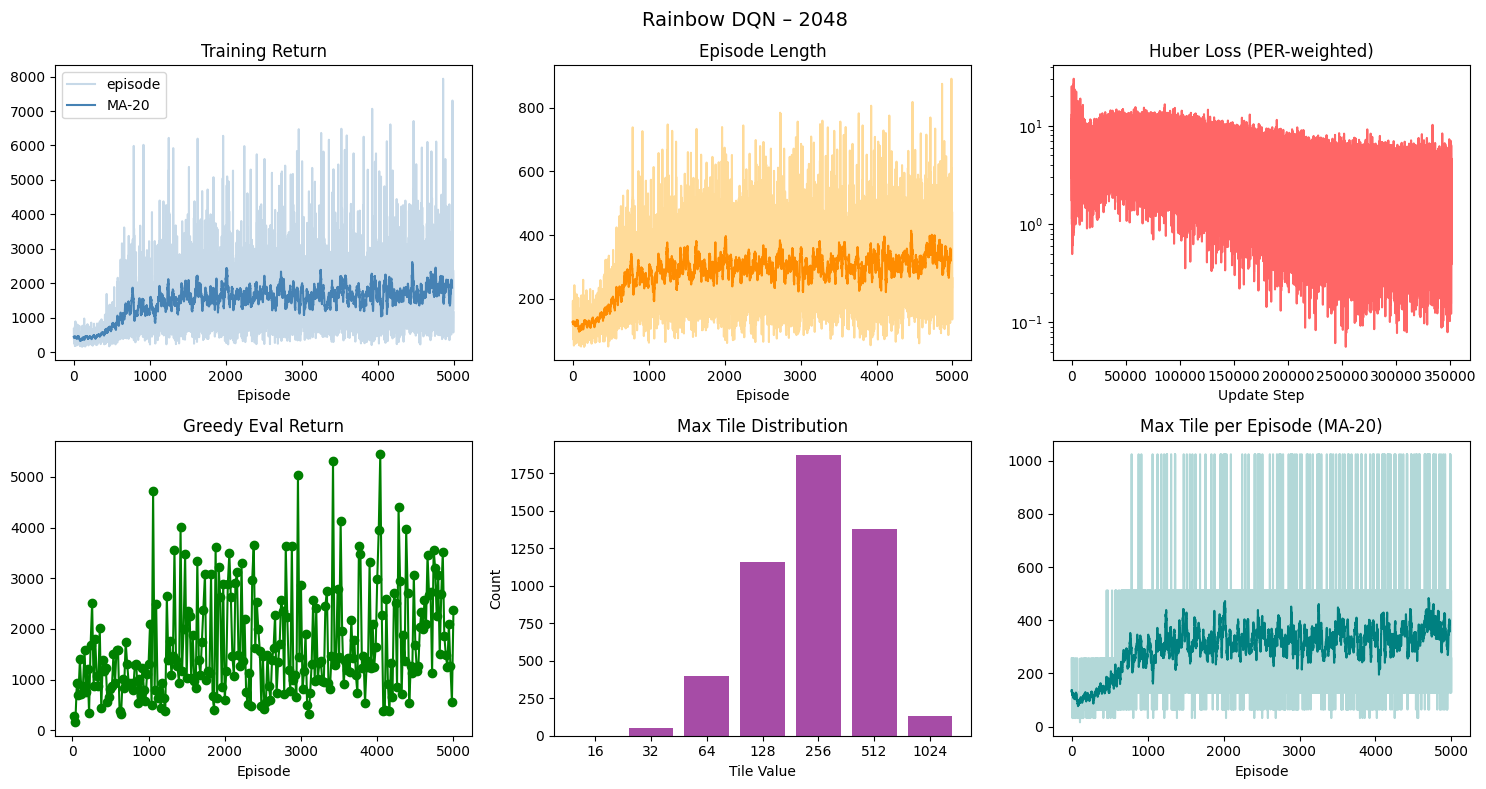


=== Summary ===
Best eval return:    5448.0
Avg last-20 return:  1869.4
  Tile    16:   1 times (0.0%)
  Tile    32:  54 times (1.1%)
  Tile    64: 398 times (8.0%)
  Tile   128: 1160 times (23.2%)
  Tile   256: 1874 times (37.5%)
  Tile   512: 1382 times (27.6%)
  Tile  1024: 131 times (2.6%)


In [ ]:
def moving_average(x, w=20):
    if len(x) < w:
        return np.asarray(x)
    return np.convolve(x, np.ones(w)/w, mode="valid")


fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Rainbow DQN – 2048", fontsize=14)

# 1. Training return
ax = axes[0, 0]
ax.plot(episode_returns, alpha=0.3, color="steelblue", label="episode")
ma = moving_average(episode_returns, 20)
ax.plot(range(len(ma)), ma, color="steelblue", label="MA-20")
ax.set_title("Training Return")
ax.set_xlabel("Episode")
ax.legend()

# 2. Episode length
ax = axes[0, 1]
ax.plot(episode_lengths, alpha=0.4, color="orange")
ma_len = moving_average(episode_lengths, 20)
ax.plot(range(len(ma_len)), ma_len, color="darkorange")
ax.set_title("Episode Length")
ax.set_xlabel("Episode")

# 3. Loss
ax = axes[0, 2]
ax.plot(loss_history, alpha=0.6, color="red")
ax.set_title("Huber Loss (PER-weighted)")
ax.set_xlabel("Update Step")
ax.set_yscale("log")

# 4. Eval return
ax = axes[1, 0]
if eval_returns:
    eval_eps, eval_vals = zip(*eval_returns)
    ax.plot(eval_eps, eval_vals, marker="o", color="green")
ax.set_title("Greedy Eval Return")
ax.set_xlabel("Episode")

# 5. Max tile distribution
ax = axes[1, 1]
if max_tile_history:
    unique, counts = np.unique(max_tile_history, return_counts=True)
    ax.bar([str(u) for u in unique], counts, color="purple", alpha=0.7)
ax.set_title("Max Tile Distribution")
ax.set_xlabel("Tile Value")
ax.set_ylabel("Count")

# 6. Max tile over time (MA)
ax = axes[1, 2]
if max_tile_history:
    ax.plot(max_tile_history, alpha=0.3, color="teal")
    ma_tile = moving_average(max_tile_history, 20)
    ax.plot(range(len(ma_tile)), ma_tile, color="teal")
ax.set_title("Max Tile per Episode (MA-20)")
ax.set_xlabel("Episode")

plt.tight_layout()
plt.show()

# Summary stats
print("\n=== Summary ===")
print(f"Best eval return:    {max(v for _, v in eval_returns):.1f}" if eval_returns else "")
print(f"Avg last-20 return:  {np.mean(episode_returns[-20:]):.1f}")
if max_tile_history:
    unique, counts = np.unique(max_tile_history, return_counts=True)
    for tile, cnt in zip(unique, counts):
        print(f"  Tile {tile:>5}: {cnt:3d} times ({100*cnt/len(max_tile_history):.1f}%)")

## 10. Evaluate greedy policy

In [ ]:
q_net.eval()  # deterministic: NoisyNets dùng mean weights

eval_env = OpenSpiel2048Env(seed=999)
obs      = eval_env.reset(seed=999)
done     = False
greedy_return = 0.0
rollout  = []

while not done and len(rollout) < MAX_STEPS_PER_EPISODE:
    legal  = eval_env.legal_actions()
    action = greedy_action(q_net, obs, legal, num_actions, DEVICE)
    next_obs, reward, done, info = eval_env.step(action)
    rollout.append({
        "action": action,
        "reward": reward,
        "board":  info["board"],
        "state_text": info["state_text"],
    })
    obs = next_obs
    greedy_return += reward

print(f"Greedy eval return: {greedy_return:.1f}")
print(f"Steps: {len(rollout)}")
if rollout and rollout[-1]["board"] is not None:
    print(f"Max tile: {rollout[-1]['board'].max()}")
eval_env.render()

Greedy eval return: 1285.0
Steps: 295
Max tile: 256
   64  256  128   64
   16   32   16    4
    8   16    8   16
    2    8    4    2



In [ ]:
# Hiển thị 5 nước đi cuối
n_show = min(5, len(rollout))
for i, step_info in enumerate(rollout[-n_show:], start=len(rollout)-n_show+1):
    action_names = ["UP", "DOWN", "LEFT", "RIGHT"]
    print("=" * 60)
    print(f"Step {i} | action={action_names[step_info['action']]} | reward={step_info['reward']:.2f}")
    if step_info["board"] is not None:
        print(step_info["board"])
    print(step_info["state_text"])

Step 291 | action=DOWN | reward=2.72
[[ 64 256 128  64]
 [ 16  32  16   4]
 [  8  16   8  16]
 [  0   2   4   2]]
   64  256  128   64
   16   32   16    4
    8   16    8   16
    0    2    4    2

Step 292 | action=RIGHT | reward=2.44
[[ 64 256 128  64]
 [ 16  32  16   4]
 [  8  16   8  16]
 [  2   4   2   2]]
   64  256  128   64
   16   32   16    4
    8   16    8   16
    2    4    2    2

Step 293 | action=RIGHT | reward=2.99
[[ 64 256 128  64]
 [ 16  32  16   4]
 [  8  16   8  16]
 [  2   4   4   2]]
   64  256  128   64
   16   32   16    4
    8   16    8   16
    2    4    4    2

Step 294 | action=RIGHT | reward=3.47
[[ 64 256 128  64]
 [ 16  32  16   4]
 [  8  16   8  16]
 [  2   8   2   2]]
   64  256  128   64
   16   32   16    4
    8   16    8   16
    2    8    2    2

Step 295 | action=RIGHT | reward=2.99
[[ 64 256 128  64]
 [ 16  32  16   4]
 [  8  16   8  16]
 [  2   8   4   2]]
   64  256  128   64
   16   32   16    4
    8   16    8   16
    2    8    4    2



## 11. Save model

In [ ]:
checkpoint_path = "rainbow_dqn_2048.pt"
torch.save(
    {
        "model_state_dict":  q_net.state_dict(),
        "target_state_dict": target_net.state_dict(),
        "obs_dim":           obs_dim,
        "num_actions":       num_actions,
        "episode_returns":   episode_returns,
        "episode_lengths":   episode_lengths,
        "loss_history":      loss_history,
        "max_tile_history":  max_tile_history,
        "hyperparams": {
            "N_STEPS":    N_STEPS,
            "PER_ALPHA":  PER_ALPHA,
            "TAU":        TAU,
            "GAMMA":      GAMMA,
        },
    },
    checkpoint_path,
)
print("Saved:", checkpoint_path)

# Load lại:
# ckpt = torch.load("rainbow_dqn_2048.pt")
# q_net = RainbowQNetwork(ckpt['obs_dim'], ckpt['num_actions']).to(DEVICE)
# q_net.load_state_dict(ckpt['model_state_dict'])
# q_net.eval()

Saved: rainbow_dqn_2048.pt
